In [51]:
from dlfs.base import Module, Loss, Optimizer, Layer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer, ConvLayer, ConvTransposeLayer, MaxPoolLayer
from dlfs.activation import ReLU, Sigmoid, GELU, LeakyReLU, Tanh

from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.optimizers import Optimizer_Adam, Optimizer_AdamW
from dlfs.helpers import get_random_batch

import numpy as np
import matplotlib.pyplot as plt

In [52]:
class DiffusionModelo(Module):

    def __init__(self, time_dim=32):
        self.fc1 = DenseLayer(1, 32)
        self.fc2 = DenseLayer(32, 32)
        self.fc3 = DenseLayer(32, 1)

        self.relu1 = ReLU()
        self.relu2 = ReLU()

        self.fc_time = DenseLayer(time_dim, 1)
        self.time_dim = time_dim

    def timestep_embedding(self, t, dim):
        t = np.asarray(t).reshape(-1, 1)
        half_dim = dim // 2

        i = np.arange(half_dim, dtype=np.float32)
        freqs = np.exp(-np.log(10000) * (2 * i / dim))  # stable version
        args = t * freqs

        return np.concatenate([np.sin(args), np.cos(args)], axis=-1)
        
    def forward(self, x, t, training=False):

        # Create time embedding
        t_emb = self.timestep_embedding(t, self.time_dim)
        # Project time embedding to input data shape
        self.fc_time.forward(t_emb)

        x_emb = x + self.fc_time.output

        self.fc1.forward(x_emb)
        self.relu1.forward(self.fc1.output)

        self.fc2.forward(self.relu1.output)
        self.relu2.forward(self.fc2.output)

        self.fc3.forward(self.relu2.output)
        self.output = self.fc3.output

    def backward(self, delta):
        self.fc3.backward(delta)

        self.relu2.backward(self.fc3.dinputs)
        self.fc2.backward(self.relu2.dinputs)

        self.relu1.backward(self.fc2.dinputs)
        self.fc1.backward(self.relu1.dinputs)
        self.fc_time.backward(self.fc1.dinputs)
        self.dinputs = self.fc_time.dinputs

In [53]:
class Diffusion(Module):

    def __init__(self, model, timesteps=1000, loss_function=None, optimizer=None):
        self.model = model
        self.timesteps = timesteps

        self.betas = np.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.ac = np.sqrt(self.alphas_cumprod)
        self.om = np.sqrt(1 - self.alphas_cumprod)

        self.loss_function = loss_function
        self.optimizer = optimizer

    def forward_diffusion(self, x0, t):

        # Compute coefficients for each batch item
        # reshape to (batch, 1, 1, 1) for broadcasting
        ac_t = self.ac[t].reshape(-1, 1)
        om_t = self.om[t].reshape(-1, 1)

        # Sample noise of same shape as x0
        noise = np.random.randn(*x0.shape)

        # Forward diffusion formula
        x_t = ac_t * x0 + om_t * noise

        return x_t, noise

    def forward(self, x, training=False):

        # Get batch size
        B = x.shape[0]

        # Generate B random timesteps
        t = np.random.randint(0, self.timesteps, size=(B, ))

        # Get noisy output and noise
        x_t, noise = self.forward_diffusion(x, t)

        self.model.forward(x_t, t, training=training)
        self.output = self.model.output
        self.noise_output = noise

    def backward(self, predicted, noise):

        self.loss_function.backward(predicted, noise)
        self.model.backward(self.loss_function.dinputs)

    def print_grads(self, layer):

        if isinstance(layer, Layer):
            params = layer.get_parameters()
            if params is None:
                return

            for name in params:
                param = getattr(layer, 'd'+name)
                print(f'{layer.__class__.__name__} grad {name}: {np.linalg.norm(param)}')

        if isinstance(layer, list):
            for l in layer:
                self.print_grads(l)

        if isinstance(layer, Module):
            for name, attr in vars(layer).items():
                self.print_grads(attr)

    def train(self, X: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None) -> None:

        # Store loss values for plotting
        self.loss_vals = []

        for i in range(epochs + 1):

            # Forward pass
            self.forward(X, training=True)

            # Backward pass
            self.backward(self.output, self.noise_output)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            #self.print_grads(self)

            # Store current loss
            loss = self.loss_function.calculate(self.output, self.noise_output)
            self.loss_vals.append(loss)

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss} ===== mu: {np.mean(self.output)} std: {np.std(self.output)}')

    def generate(self, B, C):
        
        x_t = np.random.randn(B, C).astype(np.float32)  # start from pure Gaussian noise

        for t in reversed(range(self.timesteps)):
            t_arr = np.array([t] * B).reshape(-1)
            #print(f'tarr: {t_arr.shape}')
            
            # Predict noise
            self.model.forward(x_t, t_arr, training=False)
            epsilon_pred = self.model.output
            
            # DDPM reverse diffusion formula
            alpha_t = self.alphas[t]
            alpha_cumprod_t = self.alphas_cumprod[t]
            beta_t = self.betas[t]
            
            # Predict mean of x_{t-1}
            mean = (1 / np.sqrt(alpha_t)) * (x_t - (beta_t / np.sqrt(1 - alpha_cumprod_t)) * epsilon_pred)
            
            # Sample x_{t-1} with noise if t > 0
            if t > 0:
                noise = np.random.randn(*x_t.shape)
                x_t = mean + np.sqrt(beta_t) * noise
            else:
                x_t = mean

        generated = x_t  # shape: (B, C, H, W)
        #images_uint8 = (np.clip(generated, 0, 1) * 255).astype(np.uint8)

        return generated

In [54]:
data = np.linspace(-1, 1, 500)  # shape: [16,1]
data = np.expand_dims(data, axis=1)
target = data ** 3  # some simple transformation as the "true" signal

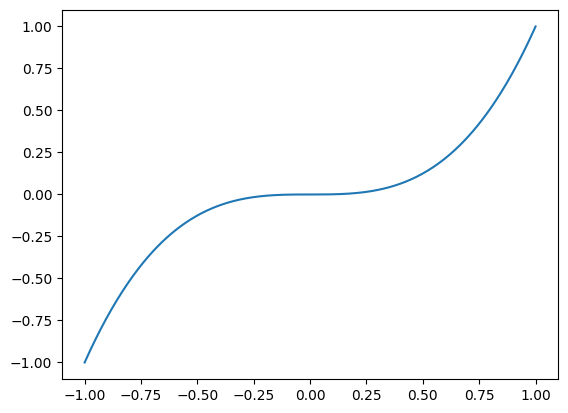

In [55]:
plt.plot(data, target)
plt.show()

In [56]:
lr=1e-2
epochs=5000

loss = MSE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr)

unet = DiffusionModelo(time_dim=128)

diffusion = Diffusion(model=unet, loss_function=loss, optimizer=optimizer)

diffusion.train(target, print_every=100, epochs=epochs)

===== EPOCH : 0 ===== LOSS : 1.8821611586523832 ===== mu: -1.2510609375521733 std: 1.0195917751812338
===== EPOCH : 100 ===== LOSS : 0.09290427506004782 ===== mu: 0.0034653674518152827 std: 0.9101619875776562
===== EPOCH : 200 ===== LOSS : 0.07379246179919795 ===== mu: 0.021207075036982423 std: 0.8908777820959146
===== EPOCH : 300 ===== LOSS : 0.06978537792543046 ===== mu: -0.0332820774939468 std: 0.8637365457854599
===== EPOCH : 400 ===== LOSS : 0.07054712353037866 ===== mu: 0.037551387924800464 std: 0.9448409585773898
===== EPOCH : 500 ===== LOSS : 0.06055803513625102 ===== mu: 0.09913390923862715 std: 0.8944419742802078
===== EPOCH : 600 ===== LOSS : 0.08464295527604127 ===== mu: 0.03534573885590338 std: 0.871829078742559
===== EPOCH : 700 ===== LOSS : 0.07879710747816109 ===== mu: -0.03111372136351399 std: 0.9110958036919015
===== EPOCH : 800 ===== LOSS : 0.05845373439568801 ===== mu: 0.08606356148015677 std: 0.9156478215136621
===== EPOCH : 900 ===== LOSS : 0.07598663453012748 ===

In [57]:
new = diffusion.generate(500, 1)

In [58]:
print(np.max(new), np.min(new))

1.199050593839903 -1.0878610446691679
